In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import torch
import sys
import os
import joblib
from scipy.spatial.distance import pdist,squareform
from SASNE import SASNE
from RRP import RRP
from functools import partial
from plotting import update, add_pointer_ani
from matplotlib import rc
rc('animation', html='jshtml')
from matplotlib.animation import FuncAnimation
import numpy as np

In [2]:
def add_pointer_ani(ax, index, label, color, offset=(40, 40)):
    return ax.annotate(label, 
                xy=(embedding[index, 0], embedding[index, 1]), 
                xytext=offset, 
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color=color, lw=2),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8),
                fontsize=10, fontweight='bold', color=color)

def update(frame):
    # Update scatter points
    current_data = embedding[:frame+1]
    sc.set_offsets(current_data)
    sc.set_array(np.arange(frame + 1))
    
    # Check for milestones to trigger annotations
    if frame == 0 and 'start' not in milestones:
        milestones['start'] = add_pointer_ani(ax, 0, 'Start (t=T)', 'red', (-60, 40))
    
    if frame == ts_idx and 'ts' not in milestones:
        milestones['ts'] = add_pointer_ani(ax, ts_idx, 'Speciation ($t_s$)', 'darkcyan', (40, 40))
        
    if frame == n_frames - 1 and 'end' not in milestones:
        milestones['end'] = add_pointer_ani(ax, -1, 'End (T=0)', 'orange', (20, -40))
        
    return sc,

In [3]:
torch.manual_seed(123)
d = 2            # Dimension
nsamples_small_n = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
mu_star, std = torch.tensor([4.0, 4.0]), 1.0
times = np.arange(T_max, 0, -dt)
Lambda = np.linalg.norm(mu_star)**2 + std**2
t_s = np.log(Lambda) / 2
t_s_idx = next(idx for idx, t in enumerate(times) if round(t, 2) == round(t_s, 2))
print(t_s)

1.7482537641375833


In [4]:
time_indices = set(range(0, len(times), 10))
time_indices.add(t_s_idx)
diffusion_steps_idices = sorted(list(time_indices))

loaded_data = joblib.load("data/D2_N1000.jbl")
history = loaded_data["history"]
dt = loaded_data["params"]["dt"]

W_results = joblib.load("data/D2_N1000_Ws.jbl")
CTDs_results = joblib.load("data/D2_N1000_CTDs.jbl")
ctds_dict = CTDs_results["CTDs"]
SAGD_dist_matrix = joblib.load("data/D2_N1000_SAGD.jbl")

In [5]:
sasne_out = SASNE(SAGD_dist_matrix)
embedding, Z = sasne_out

# Distances remain the same regardless of visualization dimensions
D1 = squareform(pdist(embedding)) 
D2 = squareform(pdist(Z)) 

Constructing graph...
--- 0.00211 seconds elapsed ---
Computing graph distance...
--- 0.00599 seconds elapsed ---
Computing embedding...
--- 0.31357 seconds elapsed ---


In [6]:
n_frames = len(embedding)
try:
    ts_idx = diffusion_steps_idices.index(t_s_idx)
except:
    ts_idx = np.argmin(np.abs(np.array(diffusion_steps_idices) - t_s_idx))
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlim(embedding[:, 0].min() - 1, embedding[:, 0].max() + 1)
ax.set_ylim(embedding[:, 1].min() - 1, embedding[:, 1].max() + 1)
sc = ax.scatter([], [], c=[], cmap='viridis', s=30, alpha=0.7, vmin=0, vmax=n_frames)
plt.colorbar(sc, label='Step Index')
milestones = {}
ani = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)
plt.close()
ani

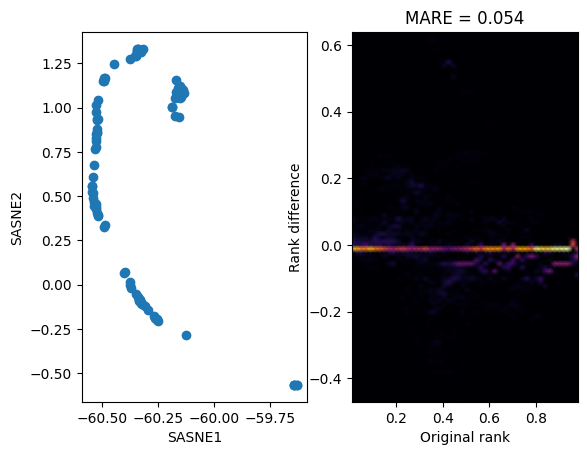

In [7]:
plt.subplot(1,2,1)
plt.scatter(embedding[:,0],embedding[:,1])
plt.xlabel('SASNE1')
plt.ylabel('SASNE2')
plt.subplot(1,2,2)
res = RRP(D1,D2) # evaluate the embedding with the RRP


plt.show()

In [8]:
print(n_frames)

101
